In [1]:
#@title Установка нужных библиотек
!wget 'https://drive.google.com/uc?export=download&id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn' -O requirements.txt
!pip install -r requirements.txt

--2026-08-11 19:04:22--  https://drive.google.com/uc?export=download&id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn
Resolving drive.google.com (drive.google.com)... 173.194.217.139, 173.194.217.113, 173.194.217.101, ...
Connecting to drive.google.com (drive.google.com)|173.194.217.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn&export=download [following]
--2026-08-11 19:04:22--  https://drive.usercontent.google.com/download?id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.11.132, 2607:f8b0:400c:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.11.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 74 [application/octet-stream]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]      74  --.-KB/s    in

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams.update({'font.size': 14})
pd.set_option('display.max_columns', 10)

**Метрики** в машинном обучении нужны для того, чтобы оценивать качество работы модели, чтобы понимать, а насколько модель хорошо запомнила закономерности из обучающей выборки.  

Сегодня продолжаем рассматривать метрики для **задачи классификации**. Для такой задачи хочется, чтобы наши модели как можно чаще предсказывали верную метку класса объекта.

<img src='https://static.javatpoint.com/tutorial/machine-learning/images/classification-algorithm-in-machine-learning.png' width=600>


Для понимания метрики ROC-AUC нужно иметь представление о матрице ошибок и о
метриках Precision и Recall, если считаете, что эти вещи нужно повторить, посмотрите [видео](https://youtu.be/AfnBHL832Eg) и почитайте [ноутбук](https://colab.research.google.com/drive/179Jm_Y2F7SnVgBK-1wj9YpsjWXb71DBN?usp=sharing).

## Получение данных

Будем считать метрику ROC-AUC на задаче бинарной классификации. Возьмем датасет из стандартных наборов данных в `sklearn` по предсказанию рака груди `load_breast_cancer`.

Здесь есть 569 объектов и 30 признаков.

In [3]:
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()

Обернем данные в датафрейм.

In [4]:
X = pd.DataFrame(data['data'], columns=data['feature_names'])
y = pd.Series(data['target'])

X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,...,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,...,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,...,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,...,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,...,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,...,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,...,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,...,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,...,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,...,0.86810,0.9387,0.2650,0.4087,0.12400


Целевая переменная из себя представляет бинарный признак:   
- 212 нулей - это класс злокачественной опухоли (Malignant).   
- А 357 единиц - класс доброкачественной опухоли (Benign).

In [5]:
y.value_counts()

,count
1,357
0,212


Разобьем выборку на обучающую и тестовую. Из исходного набора возьмем только два случайных признака, а на тест возьмем только 9 объектов для простоты подсчета метрик.

In [6]:
from sklearn.model_selection import train_test_split


np.random.seed(5)
features = np.random.randint(X.shape[1], size=2)


X_train, X_test, y_train, y_test = train_test_split(X.iloc[:, features], y, test_size=9, random_state=4)

Получили выборку для которой будем считать метрику ROC AUC.

In [7]:
X_test

,mean area,smoothness error
340,641.2,0.004577
382,447.8,0.005042
300,1217.0,0.006056
262,947.8,0.006717
363,838.1,0.007257
157,880.2,0.003443
120,403.3,0.006040
139,384.8,0.011270
99,642.5,0.008005


Шестеро из них относятся к классу 1, а трое к классу 0.

In [8]:
y_test

,0
340,1
382,1
300,0
262,0
363,1
157,1
120,1
139,1
99,0


## Обучение модели

И обучим дерево решений на классификацию опухоли.

In [9]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=1, max_depth=5, min_samples_leaf=5)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=1)

Наши модели машинного обучения на выходе могут давать метку класса, к которому принадлежит объект через метод predict.

In [10]:
tree.predict(X_test)

array([1, 1, 0, 0, 0, 0, 1, 1, 1])

А так же вероятность принадлежности к каждому классу через метод predict_proba.

In [11]:
tree.predict_proba(X_test)

array([[0.1509434 , 0.8490566 ],
       [0.03125   , 0.96875   ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.03370787, 0.96629213],
       [0.45454545, 0.54545455]])

Так как классов только два, то и видим 2 столбика, 1 столбик - это вероятность того, что объект является нулевым классом, а 2 столбик - это вероятность того, что объект первый класс.   
В сумме вероятности дают 1.   

К примеру, первый объект вероятней всего будет 1 классом (85% объект может быть 1 классом, и 15% объект может быть 0 классом), а третий объект со стопроцентной уверенностью будет 0 классом (нулевая вероятность быть 1 классом, и единичная вероятность быть 0 классом)

Оперируя вероятностями мы можем самостоятельно принимать решения выше или ниже какой отметки, объект становится нулевым классом или первым. По умолчанию такая отсечка равна 0.5.

Убедимся в этом. Руками поставим соответствующие классы на объекты с вероятностями, которые больше 0.5. То есть, если вероятность быть 1 классом, больше или равна 50%, то мы ставим объекту класс 1, если предсказанная вероятность быть 1 классом меньше 50%, то ставим объекту метку класса 0. Для этого мы взяли только первый столбик.

In [12]:
pred_proba = tree.predict_proba(X_test)
pred_proba

array([[0.1509434 , 0.8490566 ],
       [0.03125   , 0.96875   ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.03370787, 0.96629213],
       [0.45454545, 0.54545455]])

In [13]:
np.where(pred_proba[:, 1] >= 0.5, 1, 0)

array([1, 1, 0, 0, 0, 0, 1, 1, 1])

In [14]:
tree.predict(X_test)

array([1, 1, 0, 0, 0, 0, 1, 1, 1])

Получили точно такие же предсказанные метки классов, как и были после метода predict, значит точно, по умолчанию в методах predict стоит отсечка в 0.5.

## Визуализация вероятностей

Визуализируем вероятности быть 1 классом наших 9 объектов, по оси абсцисс порядковый номер объектов, а по оси ординат вероятность быть первым классом и раскрасим их в зависимости от истинной метки класса.   
Оранжевые - объекты 0 класса, синие - объекты 1 класса.

При этом есть низкой вероятностью обладают объекты как первого класса, так и нулевого.

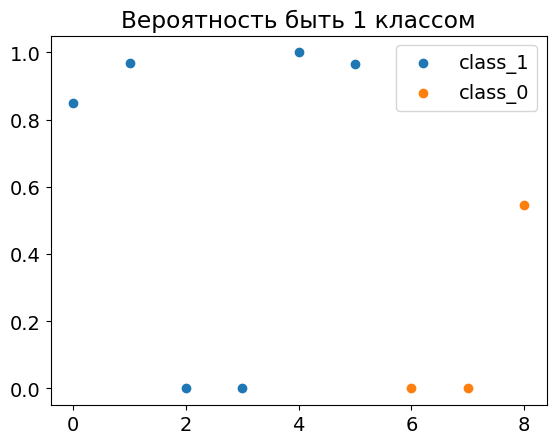

In [15]:
class_1 = pred_proba[:, 1][y_test == 1]
class_0 = pred_proba[:, 1][y_test == 0]

plt.scatter(np.arange(len(class_1)), class_1, label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0, label='class_0')
plt.title('Вероятность быть 1 классом')
plt.legend();

### Отсечка 0.5

Как мы с вами определились, по умолчанию отсечка равна 0.5. Отрисуем её тоже.   
По этой отсечке, у нас пять объектов будут классифицированы, как 1 класс, т.к. у них предсказанная вероятность больше 0.5, а четыре объекта будут классифицированы как 0 класс, т.к. их предсказанные вероятности меньше 0.5.  
При этом два объекта первого класса мы ошибочно посчитали нулевыми классами, предсказали им маленькие вероятности (0), сделали ошибки ложного пропуска False Negative.  
И ещё есть один объект с другой ошибкой - ложного срабатывания False Positive - это объект нулевого класса, который мы ошибочно посчитали объектом первого класса, т.к. ему предсказали большую вероятность быть первым классом (0.5454).

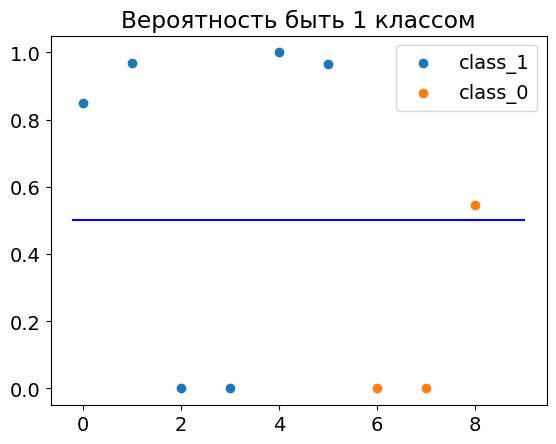

In [16]:
threshold = 0.5
class_1 = pred_proba[:, 1][y_test == 1]
class_0 = pred_proba[:, 1][y_test == 0]

plt.scatter(np.arange(len(class_1)), class_1, label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0, label='class_0')
plt.plot([-0.2, len(pred_proba[:, 1])], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Можем для такого случая отрисовать матрицу ошибок, получается 2 TN, 4 TP, 1 FP и 2 FN.   


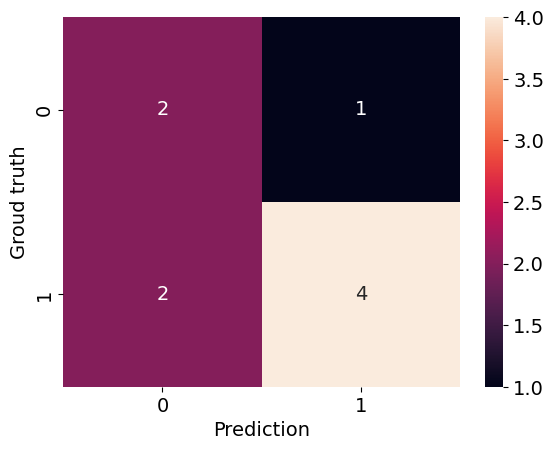

In [17]:
from sklearn.metrics import confusion_matrix


pred = np.where(pred_proba[:, 1] >= threshold, 1, 0)

cm = confusion_matrix(y_test, pred)
f = sns.heatmap(cm, annot=True)
plt.ylabel('Groud truth')
plt.xlabel('Prediction');

И теперь стоит поговорить про расчет метрики ROC-AUC. Чтобы её получить нужно оперировать двумя метриками, которые строятся на матрице ошибок - это TPR и FPR.


**TPR (True Positive Rate, доля верных срабатываний)** - отношение числа верных срабатываний к размеру положительного класса:

$$TPR = \frac{TP}{TP+FN}$$

то есть TPR по сути представляет из себя полноту - сколько раз модель правильно нашла целевой класс среди тех людей, которые действительно являются им.

Данная метрика в идеале должна стремиться к единице.


**FPR (False Positive Rate, доля ложных срабатываний)** - отношение числа ложных срабатываний к общему размеру отрицательного класса:
$$FPR = \frac{FP}{FP+TN}$$

а здесь имеем некий аналог полноты только для ошибок - сколько раз модель ошибочно нашла целевой класс среди всех людей нецелевого класса.

Данная метрика в идеале должна стремиться к нулю.


Давайте посчитаем TPR и FPR. Возьмем значения из матрицы ошибок и подставим их в формулы.

In [18]:
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

Видим, что TPR, он же recall для целевого класса на отсечке 0.5 неплохой, а FPR - recall ошибок достаточно на отсечке 0.5 небольшой, что тоже неплохо.

In [19]:
print('TPR', TP / (TP + FN))
print('FPR', FP / (FP + TN))

TPR 0.6666666666666666
FPR 0.3333333333333333


### Отсечка 0.6

При этом отсечку 0.5 мы можем менять, как захотим.

Если мы захотим увеличить чистоту классификации, а значит уменьшить FPR, то можем поднять отсечку, к примеру, до 0.6, в этом случае наша ошибка False Positive убирается, т.к. предсказанная вероятность теперь будет меньше. А значит больше нет ошибок ложного срабатывания и FPR будет равен нулю.

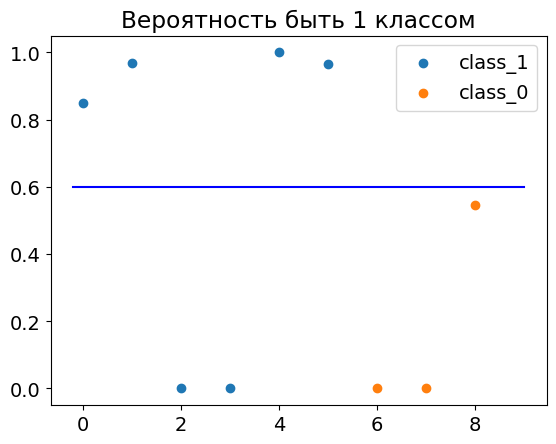

In [21]:
threshold = 0.6

class_1 = pred_proba[:, 1][y_test == 1]
class_0 = pred_proba[:, 1][y_test == 0]

pred = np.where(pred_proba[:, 1] >= threshold, 1, 0)

plt.scatter(np.arange(len(class_1)), class_1, label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0, label='class_0')
plt.plot([-0.2, len(pred_proba[:, 1])], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Посчитаем матрицу ошибок и видим, что больше ошибок ложного срабатывания нет. А значит FPR - доля ложных ошибок идеальная - нулевая.

TPR 0.6666666666666666
FPR 0.0


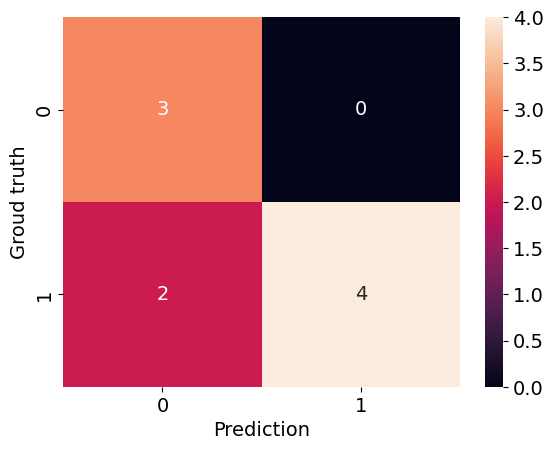

In [22]:
cm = confusion_matrix(y_test, pred)
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print('TPR', TP / (TP + FN))
print('FPR', FP / (FP + TN))

f = sns.heatmap(cm, annot=True)
plt.ylabel('Groud truth')
plt.xlabel('Prediction');

### Отсечка 0

И можем сделать по-другому: снизить отсечку до 0, тем самым будем классифицировать, как первый класс все объекты. А значит мы найдём все объекты первого класса. Ошибок ложного пропуска больше нет, метрика TPR или же Recall будет единичная.

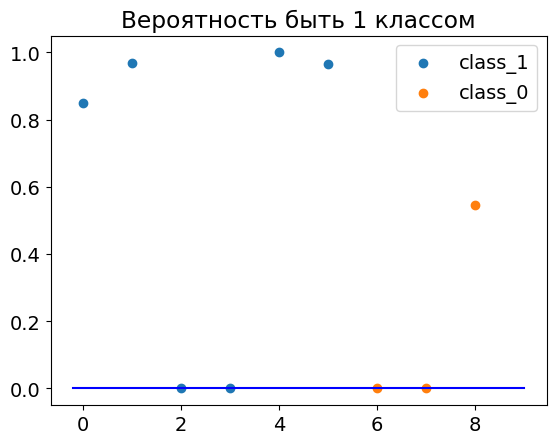

In [23]:
threshold = 0

class_1 = pred_proba[:, 1][y_test == 1]
class_0 = pred_proba[:, 1][y_test == 0]

pred = np.where(pred_proba[:, 1] >= threshold, 1, 0)

plt.scatter(np.arange(len(class_1)), class_1, label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0, label='class_0')
plt.plot([-0.2, len(pred_proba[:, 1])], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Посчитаем матрицу ошибок и теперь ошибок ложного пропуска больше нет, ровно как и нет классификаций в нулевом классе. Но видим, что FPR равен 1 - это плохо, это значит, что мы допустили в предсказаниях FP все возможные ошибки.

TPR 1.0
FPR 1.0


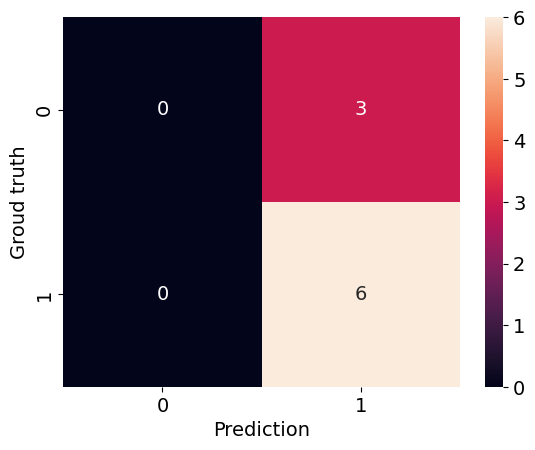

In [24]:
cm = confusion_matrix(y_test, pred)
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print('TPR', TP / (TP + FN))
print('FPR', FP / (FP + TN))

f = sns.heatmap(cm, annot=True)
plt.ylabel('Groud truth')
plt.xlabel('Prediction');

## ROC-кривая (ROC-curve)

На этих разных отсечках и строится метрика ROC-кривая и ROC-AUC. Из себя она представляет кривую, состоящую из точек с разными отсечками.  
Ниже пример ROC-кривой на обучающей выборке. Для неё выбираются разные отсечки и считаются метрики TPR и FPR, далее откладываются точки. Прямая начинается с точки (0, 0), где нулевой FPR и где нулевой TPR и заканчивается в точке (1, 1), где единичный FPR и такой же TPR.

В идеале, когда ROC-кривая проходит через точку (0, 1), где идеальный FPR нулевой - нет ни одной ошибки FP, и такой же идеальный TPR (recall), говорящий что нет ни одной ошибки FN, но на реальных данных такого не встретишь, только на синтетических искусственных выборках.

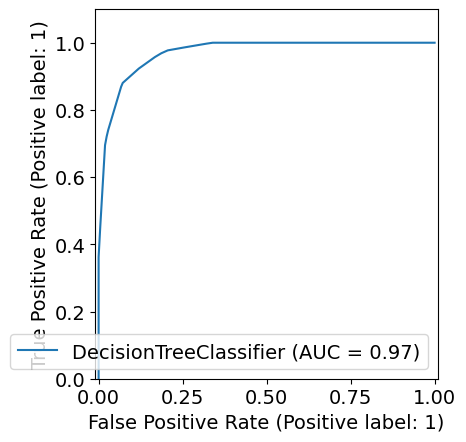

In [26]:
from sklearn.metrics import RocCurveDisplay, roc_curve
import matplotlib.pyplot as plt

# Используем метод from_estimator нового класса RocCurveDisplay
RocCurveDisplay.from_estimator(tree, X_train, y_train)
plt.ylim([0, 1.1])
plt.show()

Давайте посчитаем ROC-кривую на тестовой выборке самостоятельно.

Объединим предсказанные вероятности быть первым классом и истинные целевые значения в датафрейм и отсортируем по пробе, вначале маленькие вероятности, затем большие.

In [27]:
df_pred = pd.DataFrame({
    'proba': pred_proba[:, 1],
    'label': y_test
})

df_pred = df_pred.sort_values(by='proba')
df_pred

,proba,label
262,0.000000,0
300,0.000000,0
157,0.000000,1
363,0.000000,1
99,0.545455,0
340,0.849057,1
139,0.966292,1
382,0.968750,1
120,1.000000,1


В идеале должна существовать такая отсечка, выше которой находятся объекты только первого класса, а ниже находятся объекты нулевого класса, но в нашей задаче с такими предсказаниями не так, у нас такую границу провести не получится, всё равно будут либо ошибки ложного пропуска (FN), если поставим отсечку в 0.6, либо ошибки ложного срабатывания (FP), если поставим отсечку в 0.

### Отсечка 1

Все-таки переходим к построению ROC-кривой и начнем с подсчета удачности метрик при самой высокой отсечке равной 1.  
В этом случае у нас 8 из 9 объектов будут классифицированы, как нулевой класс, т.к. у них у всех предсказанная вероятность меньше 1 и только один объект с пробой в 1, будет отнесен моделью к первому классу.

In [28]:
threshold = 1
df_pred['pred_label'] = (df_pred['proba'] >= threshold).astype('int')

df_pred

,proba,label,pred_label
262,0.000000,0,0
300,0.000000,0,0
157,0.000000,1,0
363,0.000000,1,0
99,0.545455,0,0
340,0.849057,1,0
139,0.966292,1,0
382,0.968750,1,0
120,1.000000,1,1


Получаем, что у нас TPR будет равен $\frac{TP}{TP + FN} = \frac{1}{1 + 5} = 0.167$, потому что нашли только одну единицу из 6 возможных.

А FPR будет равен $\frac{FP}{FP + TN} = \frac{0}{0 + 3} = 0$

TPR 0.16666666666666666
FPR 0.0


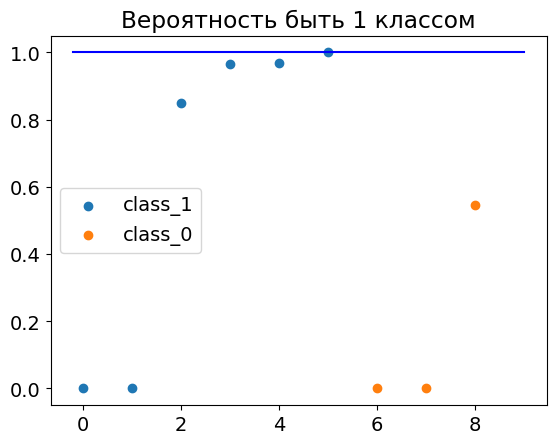

In [29]:
class_1 = df_pred[df_pred.label == 1]
class_0 = df_pred[df_pred.label == 0]

cm = confusion_matrix(df_pred['label'], df_pred['pred_label'])
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print('TPR', TPR)
print('FPR', FPR)

plt.scatter(np.arange(len(class_1)), class_1['proba'], label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0['proba'], label='class_0')
plt.plot([-0.2, len(df_pred)], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Эти значения FPR и TPR дают нам первую точку - (0.167, 0).

In [30]:
TPRs = [0]
FPRs = [0]

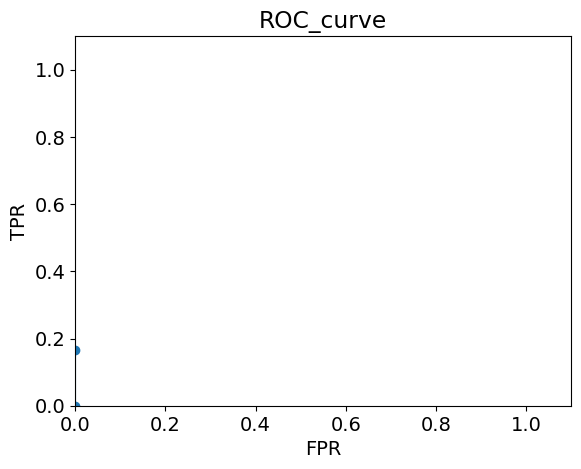

In [31]:
TPRs.append(TPR)
FPRs.append(FPR)

plt.plot(FPRs, TPRs, marker='o')
plt.ylim([0, 1.1]);plt.xlim([0, 1.1])
plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC_curve');

### Отсечка 0.84

Уменьшаем отсечку до того момента, когда мы нашли все TP до первого FP, то есть это значение отсечки 0.84. Если бы взяли отсечку больше этого значения, но меньше 1, то кривая никак не изменялась бы, увеличивался TPR, но FPR было бы равен нулю, точки стояли бы на одной линии.

Теперь 5 из 9 объектов будут классифицированы, как нулевой класс, а 4 объекта имеют пробу больше нашей отсечки, значит они будут отнесены к первому классу.

In [32]:
threshold = 0.84
df_pred['pred_label'] = (df_pred['proba'] >= threshold).astype('int')

df_pred

,proba,label,pred_label
262,0.000000,0,0
300,0.000000,0,0
157,0.000000,1,0
363,0.000000,1,0
99,0.545455,0,0
340,0.849057,1,1
139,0.966292,1,1
382,0.968750,1,1
120,1.000000,1,1


TPR будет равен $\frac{TP}{TP + FN} = \frac{4}{4 + 2} = 0.667$, потому что нашли 4 единиц из 6 возможных.

А FPR будет равен $\frac{FP}{FP + TN} = \frac{0}{0 + 3} = 0$, ещё нет ни одной неверной классификации FP.

TPR 0.6666666666666666
FPR 0.0


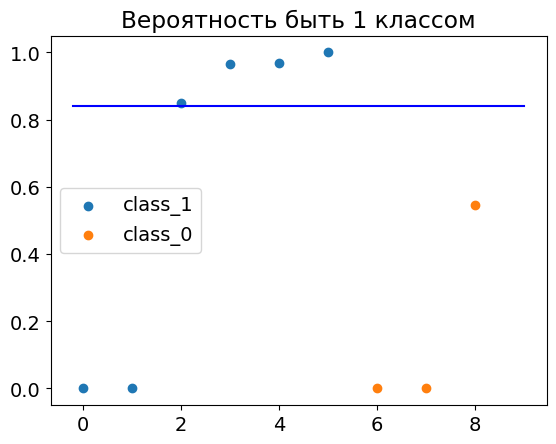

In [33]:
class_1 = df_pred[df_pred.label == 1]
class_0 = df_pred[df_pred.label == 0]

cm = confusion_matrix(df_pred['label'], df_pred['pred_label'])
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print('TPR', TPR)
print('FPR', FPR)

plt.scatter(np.arange(len(class_1)), class_1['proba'], label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0['proba'], label='class_0')
plt.plot([-0.2, len(df_pred)], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Эти значения FPR и TPR дают нам вторую точку - (0.667, 0).

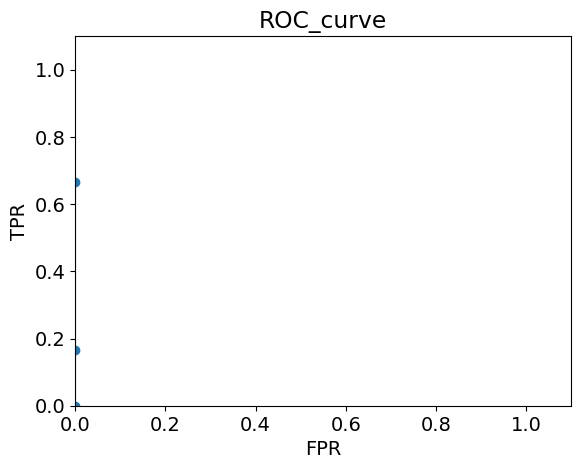

In [34]:
TPRs.append(TPR)
FPRs.append(FPR)

plt.plot(FPRs, TPRs, marker='o')
plt.ylim([0, 1.1]);plt.xlim([0, 1.1])
plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC_curve');

### Отсечка 0.54

Едем дальше и снижаем отсечку до 0.54, чтобы допустить первую ошибку FP и изменить значение метрики FPR.

Теперь 4 из 9 объектов будут классифицированы, как нулевой класс, а 5 объектов будут отнесены к первому классу.

In [35]:
threshold = 0.54
df_pred['pred_label'] = (df_pred['proba'] >= threshold).astype('int')

df_pred

,proba,label,pred_label
262,0.000000,0,0
300,0.000000,0,0
157,0.000000,1,0
363,0.000000,1,0
99,0.545455,0,1
340,0.849057,1,1
139,0.966292,1,1
382,0.968750,1,1
120,1.000000,1,1


TPR никак не изменился, нового TP не нашли и TPR будет равен $\frac{TP}{TP + FN} = \frac{4}{4 + 2} = 0.667$.

А полнота для отрицательного класса стала больше, FPR будет равен $\frac{FP}{FP + TN} = \frac{1}{1 + 2} = 0.334$

TPR 0.6666666666666666
FPR 0.3333333333333333


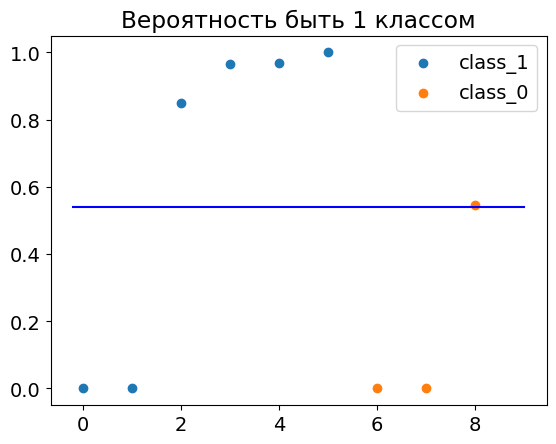

In [36]:
class_1 = df_pred[df_pred.label == 1]
class_0 = df_pred[df_pred.label == 0]

cm = confusion_matrix(df_pred['label'], df_pred['pred_label'])
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print('TPR', TPR)
print('FPR', FPR)

plt.scatter(np.arange(len(class_1)), class_1['proba'], label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0['proba'], label='class_0')
plt.plot([-0.2, len(df_pred)], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Эти значения FPR и TPR дают нам третью точку - (0.334, 0.667).

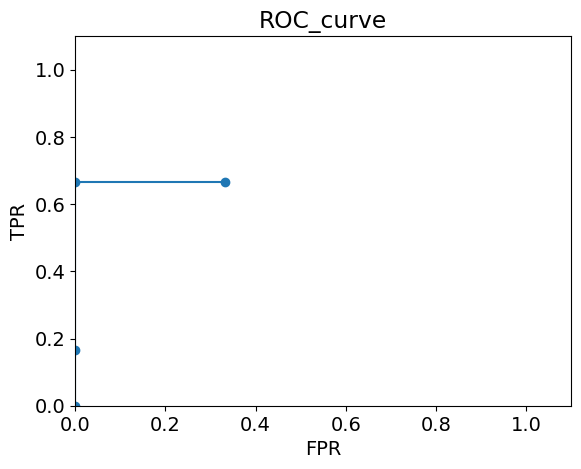

In [37]:
TPRs.append(TPR)
FPRs.append(FPR)

plt.plot(FPRs, TPRs, marker='o')
plt.ylim([0, 1.1]);plt.xlim([0, 1.1])
plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC_curve');

### Отсечка 0

Теперь снова меняем отсечку на то значение, где найдены все единицы до появления новой ошибки FP, то есть до 0.

Теперь все объекты будут классифицированы, как первый класс.

In [38]:
threshold = 0
df_pred['pred_label'] = (df_pred['proba'] >= threshold).astype('int')

df_pred

,proba,label,pred_label
262,0.000000,0,1
300,0.000000,0,1
157,0.000000,1,1
363,0.000000,1,1
99,0.545455,0,1
340,0.849057,1,1
139,0.966292,1,1
382,0.968750,1,1
120,1.000000,1,1


TPR идеальный, т.к. найдены все объекты первого класса, он равен $\frac{TP}{TP + FN} = \frac{6}{6 + 0} = 1$.

И так же для отрицательного класса, найдены все потенциальные ошибки, FPR равен $\frac{FP}{FP + TN} = \frac{3}{3 + 0} = 1$

TPR 1.0
FPR 1.0


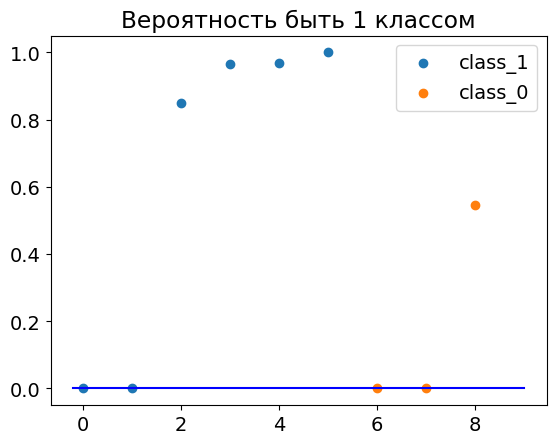

In [39]:
class_1 = df_pred[df_pred.label == 1]
class_0 = df_pred[df_pred.label == 0]

cm = confusion_matrix(df_pred['label'], df_pred['pred_label'])
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print('TPR', TPR)
print('FPR', FPR)

plt.scatter(np.arange(len(class_1)), class_1['proba'], label='class_1')
plt.scatter(np.arange(len(class_1), len(class_1)+len(class_0)), class_0['proba'], label='class_0')
plt.plot([-0.2, len(df_pred)], [threshold, threshold], c='b')
plt.title('Вероятность быть 1 классом')
plt.legend();

Эти значения FPR и TPR дают нам четвертую точку - (1, 1).

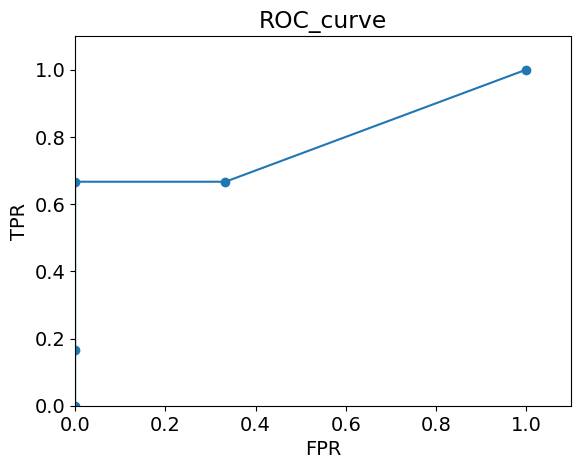

In [40]:
TPRs.append(TPR)
FPRs.append(FPR)

plt.plot(FPRs, TPRs, marker='o')
plt.ylim([0, 1.1]);plt.xlim([0, 1.1])
plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC_curve');

Такую же кривую мы могли бы получить через sklearn, если бы вызвали функцию `roc_curve`, на выходе у неё список метрик FPR, список метрик TPR и список отсечек.

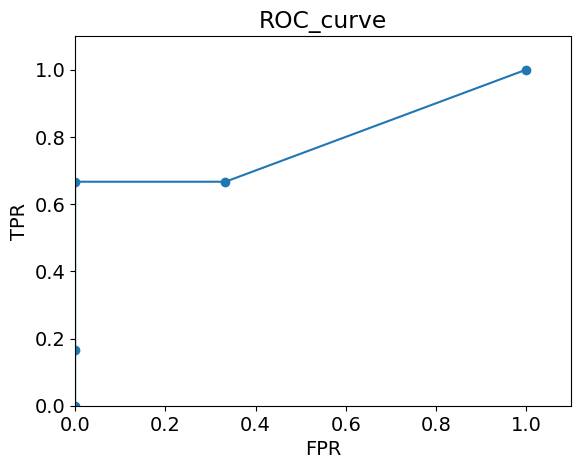

In [41]:
fprs, tprs, thr = roc_curve(y_test, pred_proba[:, 1])

plt.plot(fprs, tprs, marker='o')
plt.ylim([0, 1.1]);plt.xlim([0, 1.1])
plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC_curve');

## ROC-AUC

Так же мы можем узнать площадь под данными кривыми, результаты тоже будет одинаковыми.  
В данным случае считаем площадь через функцию `auc` (area under curve) из `sklearn`.

Получаем одинаковые метрики ROC-AUC по нашей задаче.

In [42]:
from sklearn.metrics import auc

auc(fprs, tprs), auc(FPRs, TPRs)

(np.float64(0.7777777777777778), np.float64(0.7777777777777778))

# Summary

В этом занятии посмотрели на ROC-кривую и на площадь под ней - метрику ROC-AUC. Данные метрики в большинстве своём можно считать только для задач бинарной классификации, т.к. мы оперируем вероятностями быть или не быть целевым классом. Но есть два подхода для решения задач многоклассовой классификации - OVR и OVO, как раз с помощью них и можно считать эти метрики для задач, где классов больше двух.

<table>

<tr>
<td>

<b>Метрика</b>

</td>

<td>

<b>Область определения</b>

</td>

<td>

<b>Идеал</b>

</td>

</tr>

<tr>
<td>

ROC-curve (ROC-кривая)

</td>

<td>

кривая начинается от точки (0,0)<br>и заканчивается в точке (1, 1).

</td>

<td>

Чем выше кривая, тем лучше алгоритм.

</td>

</tr>



<tr>
<td>

ROC-AUC

</td>

<td>

[0, 1]

</td>

<td>

1

</td>

</tr>


<table>

В целом, метрики используются для того, чтобы получить цифру оценки качества работы обученной модели, чтобы уже заранее знать, чего ожидать от модели, когда ей будем давать реальные данные, а также метрики можем использовать для обнаружения переобучения/недообучения. Про них разговор ведется в этом [ноутбуке](https://colab.research.google.com/drive/1MNpLMZGJCBwdNjY_PgJIKHtll6zvUEyU?usp=sharing) и в этом [видео](https://youtu.be/m7P7bnLxIc4).

Про остальные метрики для задачи классификации можно посмотреть и почитать здесь:
1. Accuracy. [ноутбук](https://colab.research.google.com/drive/1RSIGFmdzTLYEPCcZUWcWvO9-UW23Bm-K), [видео](https://youtu.be/CCH-1gJo_z0)
2. Precision, Recall. Confusion Matrix [ноутбук](https://colab.research.google.com/drive/179Jm_Y2F7SnVgBK-1wj9YpsjWXb71DBN?usp=sharing) и [видео](https://youtu.be/AfnBHL832Eg).
3. F-score [ноутбук](https://colab.research.google.com/drive/1kcB1gNIqh3fJhz5XMtEtlwpfgnj-LO_c?usp=sharing) и [видео](https://youtu.be/PeE3Fkt5W3Q).
4. Micro, Macro, Weighted [ноутбук](https://colab.research.google.com/drive/139ON75Kg39wzPiSKlex94f0nKeArZs00?usp=sharing) и [видео](https://youtu.be/i1G5F2jOspE)
5. PR-curve, PR-AUC [ноутбук](https://colab.research.google.com/drive/1oZoin7AOxCdlw7xP-1ksnLyEYCRSaj_Q?usp=sharing) и [видео](https://youtu.be/QW-09jHQH-w)


Муррр ♥